In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

In [7]:
base_case = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case10/chain.h5"
vec_all = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"
vec_diff = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case22/chain.h5"
uniform_temp = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case20/chain.h5"

In [8]:
idx_base_vavg = 25
idx_all_v_c1 = 9
idx_all_v_c2 = 19
idx_all_v_fil = 27
idx_diff_v_avg = 25
idx_diff_v_diff = 26
idx_uniform = 25

In [83]:
# latex font matplotlib
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')

In [10]:
# Get MCMC samples
sampler_base = emcee.backends.HDFBackend(base_case)
sampler_vec_all = emcee.backends.HDFBackend(vec_all)
sampler_vec_diff = emcee.backends.HDFBackend(vec_diff)
sampler_uniform = emcee.backends.HDFBackend(uniform_temp)

samples_base = sampler_base.get_chain(discard=70000, flat=True, thin=1)
samples_vec_all = sampler_vec_all.get_chain(discard=70000, flat=True, thin=1)
samples_vec_diff = sampler_vec_diff.get_chain(discard=70000, flat=True, thin=1)
samples_uniform = sampler_uniform.get_chain(discard=70000, flat=True, thin=1)

In [11]:
vector_base_vavg = samples_base[:, idx_base_vavg]
vector_all_v_c1 = samples_vec_all[:, idx_all_v_c1]
vector_all_v_c2 = samples_vec_all[:, idx_all_v_c2]
vector_all_v_fil = samples_vec_all[:, idx_all_v_fil]
vector_diff_v_avg = samples_vec_diff[:, idx_diff_v_avg]
vector_diff_v_diff = samples_vec_diff[:, idx_diff_v_diff]
vector_uniform = samples_uniform[:, idx_uniform]

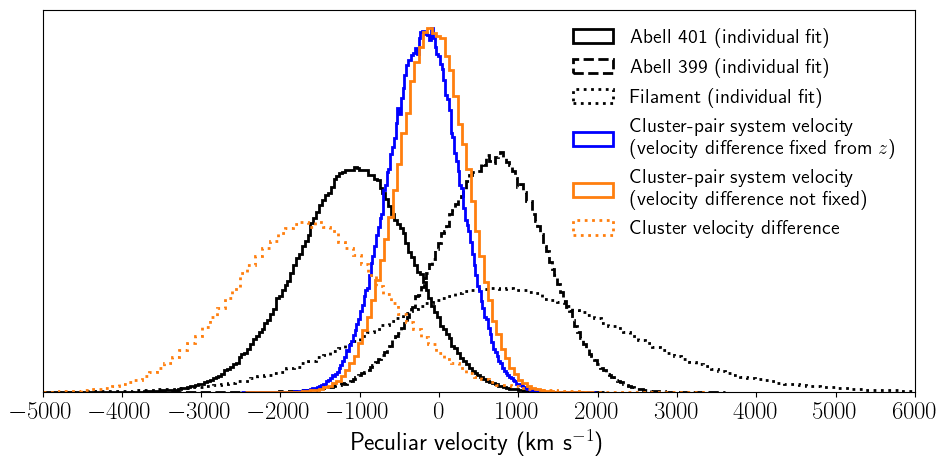

In [85]:
# plot the histograms of the vectors on the same plot
plt.figure(figsize=(10, 5))

plt.hist(vector_all_v_c1, bins=200, alpha=1, label='Abell 401 (individual fit)', 
         color='black', density=True, histtype='step', linewidth=2, linestyle='-')
plt.hist(vector_all_v_c2, bins=200, alpha=1, label='Abell 399 (individual fit)', 
         color='black', density=True, histtype='step', linewidth=2, linestyle='--')
plt.hist(vector_all_v_fil, bins=200, alpha=1, label='Filament (individual fit)', 
         color='black', density=True, histtype='step', linewidth=2, linestyle=':')

plt.hist(vector_base_vavg, bins=200, alpha=1, label='Cluster-pair system velocity \n(velocity difference fixed from $z$)', 
         color='blue', density=True, histtype='step', linewidth=2)
# plt.hist(vector_uniform, bins=200, alpha=1, label='Cluster-pair system velocity \n(Flat temperature priors, velocity difference fixed from $z$)', 
#          color='green', density=True, histtype='step', linewidth=2)

plt.hist(vector_diff_v_avg, bins=80, alpha=1, label='Cluster-pair system velocity \n(velocity difference not fixed)', 
         color='C1', density=True, histtype='step', linewidth=2, linestyle='-')
plt.hist(vector_diff_v_diff, bins=100, alpha=1, label='Cluster velocity difference', 
         color='C1', density=True, histtype='step', linewidth=2, linestyle=':')



plt.xlabel('Peculiar velocity (km s$^{-1}$)')
plt.legend(fontsize=14.5, frameon=False, loc='upper right')
plt.tight_layout()
plt.xlim(-5000, 6000)
plt.xticks(np.arange(-5000, 7000, 1000))
plt.gca().set_ylabel('')
plt.yticks([])
plt.savefig("../plots/v_compare_fit_types.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

6573000